In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [12]:
# Read the CSV file

df = pd.read_csv('cleaned_output.csv')

df

,Covidence #,Study ID,Title,Reviewer Name,Study ID (dup),Title (dup),Journal Subject Area (Scimago classification),What is the type of study?,What are the objectives of the study?,Which RL technique is used?,...,Which evaluation metrics are used?,Are results validated using statistical tests or confidence intervals?,Is the code or workflow made publicly available and referred to?,What is the implementation status?,Does the study conduct a benchmark?,What is the model benchmarked against?,Is a standard dataset used for all models?,Does study mention Transfer Learning or similar method as potential avenue for research?,Does study mention alternative generalization methods?,Does the study propose a framework to structure RL research in finance?
0,496,Chen 2024,Portfolio Allocation with Dynamic Risk Prefere...,Mathis Jander,Chen2024b,Portfolio Allocation with Dynamic Risk Prefere...,"Computer Science; Economics, Econometrics and ...",Primary,The paper proposes a reinforcement learning (R...,Policy-based Method,...,"Sharpe ratio; Other: Sortino ratio, Cumulated ...",No,No,Simulation-based,Yes,Market Indexes; Algorithmic Baselines,Yes,No,No,No
1,496,Chen 2024,Portfolio Allocation with Dynamic Risk Prefere...,Consensus,Chen2024b,Portfolio Allocation with Dynamic Risk Prefere...,"Computer Science; Economics, Econometrics and ...",Primary,The paper proposes a reinforcement learning (R...,Policy-based Method,...,"Sharpe ratio; Other: Sortino ratio, Cumulated ...",No,No,Simulation-based,Yes,Market Indexes; Algorithmic Baselines,Yes,No,No,No
2,488,Hambly 2023,Recent advances in reinforcement learning in f...,Mathis Jander,Hambly2023,Recent advances in reinforcement learning in f...,"Business, Management and Accounting; Economics...",Secondary,To review recent advancements in reinforcement...,Other: n.a.,...,Other: n.a.,No,No,Simulation-based,No,Other: n.a.,NaN,Yes,Yes,Yes
3,488,Hambly 2023,Recent advances in reinforcement learning in f...,Consensus,Hambly2023,Recent advances in reinforcement learning in f...,"Business, Management and Accounting; Economics...",Secondary,To review recent advancements in reinforcement...,Other: n.a.,...,Other: n.a.,No,No,Simulation-based,No,Other: n.a.,NaN,Yes,Yes,Yes
4,485,Barbieri 2020,Discrete-Event Simulation-Based Q-Learning Alg...,Mathis Jander,Barbieri 2020,Discrete‑Event Simulation‑Based Q‑Learning Alg...,Computer Science,Primary,Combine discrete-event simulation with RL for ...,Value-based Method,...,PnL,No,No,Simulation-based,No,NaN,NaN,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,3,Aboussalah 2020,Continuous control with Stacked Deep Dynamic R...,Consensus,Aboussalah 2020,Continuous control with Stacked Deep Dynamic R...,"Computer Science, Engineering",Primary,Develop new RL algorithm for continuous action...,Actor-Critic Method,...,Sharpe ratio; PnL; Other: Annualized return,No,No,Simulation-based,Yes,Random or Naive Strategies; Algorithmic Baselines,Yes,No,No,No
322,2,Liang 2023,Crude oil price prediction using deep reinforc...,Mathis Jander,Liang2023,Crude oil price prediction using deep reinforc...,"Economics, Econometrics and Finance; Environme...",Primary,Develop a deep reinforcement learning (DRL) al...,Actor-Critic Method,...,"Other: MAE, MSE, RMSE, MAPE",No,No,Simulation-based,Yes,Algorithmic Baselines; State of the Art Algori...,Yes,No,No,No
323,2,Liang 2023,Crude oil price prediction using deep reinforc...,Consensus,Liang2023,Crude oil price prediction using deep reinforc...,"Economics, Econometrics and Finance; Environme...",Primary,Develop a deep reinforcement learning (DRL) al...,Actor-Critic Method,...,"Other: MAE, MSE, RMSE, MAPE",No,No,Simulation-based,Yes,Algorithmic Baselines; State of the Art Algori...,Yes,No,No,No
324,1,Lu 2022,Structural break-aware pairs trading strategy ...,Mathis Jander,Lu2022,Structural break‑aware pairs trading strategy ...,"Computer Science, Mathematics",Primary,Develop a two-phase machine learning

In [13]:
# only selected rows where reviewer name is Consensus

df_consensus = df[df['Reviewer Name'] == 'Consensus'].reset_index(drop=True)
df_consensus

,Covidence #,Study ID,Title,Reviewer Name,Study ID (dup),Title (dup),Journal Subject Area (Scimago classification),What is the type of study?,What are the objectives of the study?,Which RL technique is used?,...,Which evaluation metrics are used?,Are results validated using statistical tests or confidence intervals?,Is the code or workflow made publicly available and referred to?,What is the implementation status?,Does the study conduct a benchmark?,What is the model benchmarked against?,Is a standard dataset used for all models?,Does study mention Transfer Learning or similar method as potential avenue for research?,Does study mention alternative generalization methods?,Does the study propose a framework to structure RL research in finance?
0,496,Chen 2024,Portfolio Allocation with Dynamic Risk Prefere...,Consensus,Chen2024b,Portfolio Allocation with Dynamic Risk Prefere...,"Computer Science; Economics, Econometrics and ...",Primary,The paper proposes a reinforcement learning (R...,Policy-based Method,...,"Sharpe ratio; Other: Sortino ratio, Cumulated ...",No,No,Simulation-based,Yes,Market Indexes; Algorithmic Baselines,Yes,No,No,No
1,488,Hambly 2023,Recent advances in reinforcement learning in f...,Consensus,Hambly2023,Recent advances in reinforcement learning in f...,"Business, Management and Accounting; Economics...",Secondary,To review recent advancements in reinforcement...,Other: n.a.,...,Other: n.a.,No,No,Simulation-based,No,Other: n.a.,NaN,Yes,Yes,Yes
2,485,Barbieri 2020,Discrete-Event Simulation-Based Q-Learning Alg...,Consensus,Barbieri 2020,Discrete‑Event Simulation‑Based Q‑Learning Alg...,Computer Science,Primary,Combine discrete-event simulation with RL for ...,Value-based Method,...,PnL,No,No,Simulation-based,No,NaN,NaN,No,No,No
3,477,Li 2021,Take Bitcoin into your portfolio: a novel ense...,Consensus,Li2021,Take Bitcoin into your portfolio: a novel ense...,"Business, Management and Accounting; Economics...",Primary,Design a novel ensemble portfolio optimization...,Other: not defined,...,"Sharpe ratio; Other: Return, Volatility, MSE, ...",No,No,Simulation-based,Yes,Market Indexes; Random or Naive Strategies,Yes,No,No,No
4,461,Song 2024,Developing an investment method for securities...,Consensus,Song2024,Developing an Investment Method for Securities...,"Computer Science, Engineering, Materials Science",Primary,Propose and empirically test an investment str...,Actor-Critic Method,...,Sharpe ratio; Max drawdown; Other: Calmar rati...,No,No,Simulation-based,Yes,Algorithmic Baselines; State of the Art Algori...,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,5,Felizardo 2022,Outperforming algorithmic trading reinforcemen...,Consensus,Felizardo2022,Outperforming algorithmic trading reinforcemen...,"Computer Science, Engineering",Primary,The study compares reinforcement learning (RL)...,Value-based Method; Policy-based Method; Actor...,...,"Sharpe ratio; Other: Annualized returns, Area ...",No,Yes,Simulation-based,Yes,Market Indexes; State of the Art Algorithms,Yes,No,No,No
159,4,Park 2024,Deep Reinforcement Learning Robots for Algorit...,Consensus,Park2024b,Deep Reinforcement Learning Robots for Algorit...,"Computer Science, Engineering, Materials Science",Primary,Build DRL-based stock trading robots using PPO...,Actor-Critic Method,...,Other: Reward,No,No,Simulation-based,Yes,Other: Two versions of proposed model,Yes,No,No,No
160,3,Aboussalah 2020,Continuous control with Stacked Deep Dynamic R...,Consensus,Aboussalah 2020,Continuous control with Stacked Deep Dynamic R...,"Computer Science, Engineering",Primary,Develop new RL algorithm for continuous action...,Actor-Critic Method,...,Sharpe ratio; PnL; Other: Annualized return,No,No,Simulation-based,Yes,Random or Naive Strategies; Algorithmic Baselines,Yes,No,No,No
161,2,Liang 2023,Crude oil price prediction using deep reinforc...,Consensus,Liang2023,Crude oil price prediction using deep reinforc...,"Economics

In [17]:
# create new column called Year with the year extracted from the Study ID column

df_consensus['Year'] = df_consensus['Study ID'].str.extract(r'(\d{4})').astype(int)
# create a new column called Year Group based on the Year column
df_consensus

,Covidence #,Study ID,Title,Reviewer Name,Study ID (dup),Title (dup),Journal Subject Area (Scimago classification),What is the type of study?,What are the objectives of the study?,Which RL technique is used?,...,Are results validated using statistical tests or confidence intervals?,Is the code or workflow made publicly available and referred to?,What is the implementation status?,Does the study conduct a benchmark?,What is the model benchmarked against?,Is a standard dataset used for all models?,Does study mention Transfer Learning or similar method as potential avenue for research?,Does study mention alternative generalization methods?,Does the study propose a framework to structure RL research in finance?,Year
0,496,Chen 2024,Portfolio Allocation with Dynamic Risk Prefere...,Consensus,Chen2024b,Portfolio Allocation with Dynamic Risk Prefere...,"Computer Science; Economics, Econometrics and ...",Primary,The paper proposes a reinforcement learning (R...,Policy-based Method,...,No,No,Simulation-based,Yes,Market Indexes; Algorithmic Baselines,Yes,No,No,No,2024
1,488,Hambly 2023,Recent advances in reinforcement learning in f...,Consensus,Hambly2023,Recent advances in reinforcement learning in f...,"Business, Management and Accounting; Economics...",Secondary,To review recent advancements in reinforcement...,Other: n.a.,...,No,No,Simulation-based,No,Other: n.a.,NaN,Yes,Yes,Yes,2023
2,485,Barbieri 2020,Discrete-Event Simulation-Based Q-Learning Alg...,Consensus,Barbieri 2020,Discrete‑Event Simulation‑Based Q‑Learning Alg...,Computer Science,Primary,Combine discrete-event simulation with RL for ...,Value-based Method,...,No,No,Simulation-based,No,NaN,NaN,No,No,No,2020
3,477,Li 2021,Take Bitcoin into your portfolio: a novel ense...,Consensus,Li2021,Take Bitcoin into your portfolio: a novel ense...,"Business, Management and Accounting; Economics...",Primary,Design a novel ensemble portfolio optimization...,Other: not defined,...,No,No,Simulation-based,Yes,Market Indexes; Random or Naive Strategies,Yes,No,No,No,2021
4,461,Song 2024,Developing an investment method for securities...,Consensus,Song2024,Developing an Investment Method for Securities...,"Computer Science, Engineering, Materials Science",Primary,Propose and empirically test an investment str...,Actor-Critic Method,...,No,No,Simulation-based,Yes,Algorithmic Baselines; State of the Art Algori...,Yes,No,Yes,No,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,5,Felizardo 2022,Outperforming algorithmic trading reinforcemen...,Consensus,Felizardo2022,Outperforming algorithmic trading reinforcemen...,"Computer Science, Engineering",Primary,The study compares reinforcement learning (RL)...,Value-based Method; Policy-based Method; Actor...,...,No,Yes,Simulation-based,Yes,Market Indexes; State of the Art Algorithms,Yes,No,No,No,2022
159,4,Park 2024,Deep Reinforcement Learning Robots for Algorit...,Consensus,Park2024b,Deep Reinforcement Learning Robots for Algorit...,"Computer Science, Engineering, Materials Science",Primary,Build DRL-based stock trading robots using PPO...,Actor-Critic Method,...,No,No,Simulation-based,Yes,Other: Two versions of proposed model,Yes,No,No,No,2024
160,3,Aboussalah 2020,Continuous control with Stacked Deep Dynamic R...,Consensus,Aboussalah 2020,Continuous control with Stacked Deep Dynamic R...,"Computer Science, Engineering",Primary,Develop new RL algorithm for continuous action...,Actor-Critic Method,...,No,No,Simulation-based,Yes,Random or Naive Strategies; Algorithmic Baselines,Yes,No,No,No,2020
161,2,Liang 2023,Crude oil price prediction using deep reinforc...,Consensus,Liang2023,Crude oil price prediction using deep reinforc...,"Economics, Econometrics and Finance; Environme...",Primary,Develop a deep reinforcement learning (DRL) al...,Actor-Critic Method,...,No,No,Simulation-based,Yes,Algorithmic Baselines; State of the Art Algori...,Yes,No,No,No,2023


# 1 General Analysis

In [21]:
# count number of studies
df_consensus.shape[0]

163

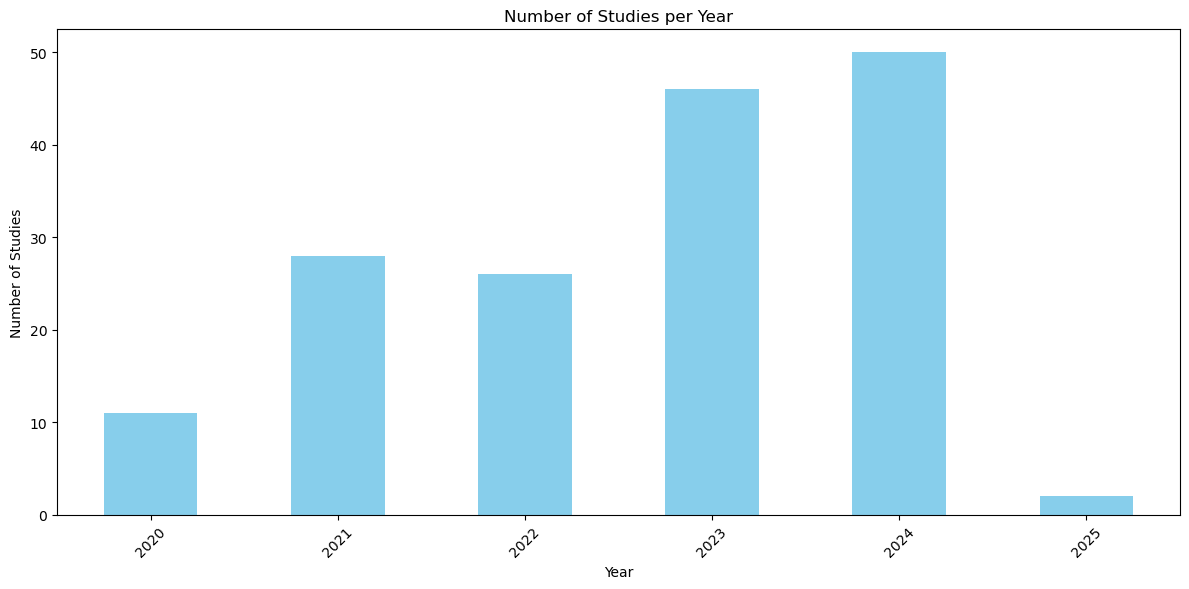

In [ ]:
# plot number of studies per year
plt.figure(figsize=(12, 6))
df_consensus['Year'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Number of Studies per Year')
plt.xlabel('Year')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

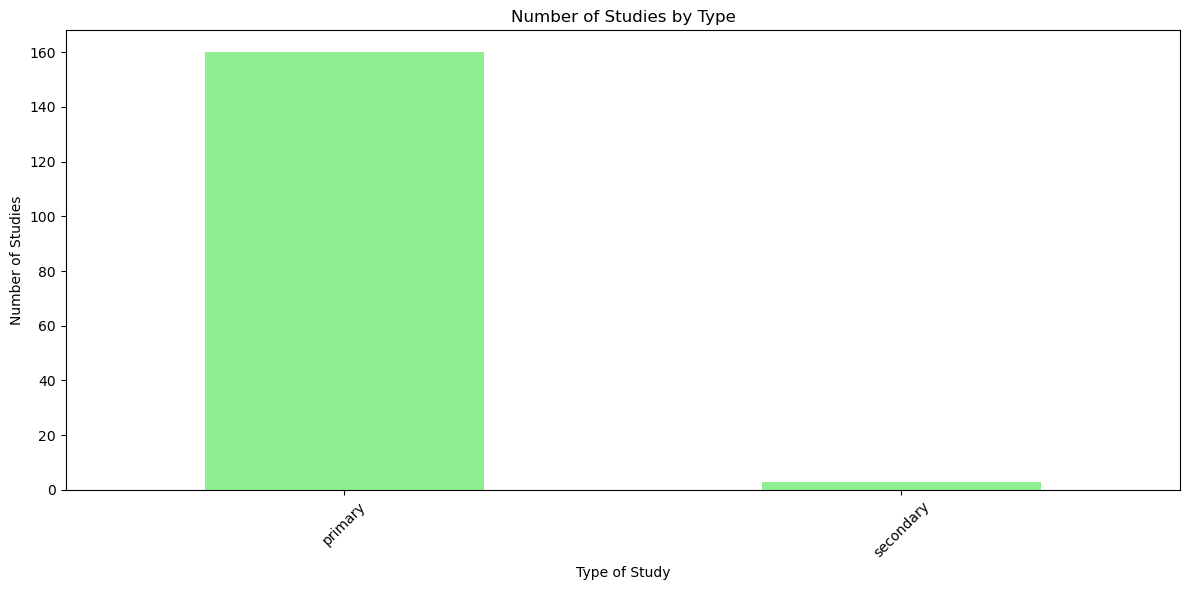

In [27]:
# make all values in the 'What is the type of study?' column lowercase
df_consensus['What is the type of study?'] = df_consensus['What is the type of study?'].str.lower().replace('other: primary', 'primary')

# plot by type of study
plt.figure(figsize=(12, 6))
df_consensus['What is the type of study?'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Number of Studies by Type')
plt.xlabel('Type of Study')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [36]:
raw_tech = df_consensus['Which RL technique is used?']

# split the raw_tech into a list of techniques by splitting on semicolon and stripping whitespace
tech_list = [tech.strip() for sublist in raw_tech for tech in sublist.split(';') if tech.strip()]

# Replace entries containing 'Other' with 'Unspecified/Other'
standardized_techs = [
    'Unspecified/Other' if 'other' in tech.lower() else tech
    for tech in tech_list
]

standardized_techs

['Policy-based Method',
 'Unspecified/Other',
 'Value-based Method',
 'Unspecified/Other',
 'Actor-Critic Method',
 'Value-based Method',
 'Unspecified/Other',
 'Value-based Method',
 'Policy-based Method',
 'Value-based Method',
 'Value-based Method',
 'Value-based Method',
 'Actor-Critic Method',
 'Actor-Critic Method',
 'Value-based Method',
 'Value-based Method',
 'Policy-based Method',
 'Value-based Method',
 'Value-based Method',
 'Actor-Critic Method',
 'Value-based Method',
 'Policy-based Method',
 'Policy-based Method',
 'Policy-based Method',
 'Value-based Method',
 'Actor-Critic Method',
 'Value-based Method',
 'Value-based Method',
 'Policy-based Method',
 'Actor-Critic Method',
 'Model-based Method',
 'Actor-Critic Method',
 'Policy-based Method',
 'Actor-Critic Method',
 'Unspecified/Other',
 'Value-based Method',
 'Policy-based Method',
 'Actor-Critic Method',
 'Value-based Method',
 'Unspecified/Other',
 'Policy-based Method',
 'Value-based Method',
 'Policy-based Metho

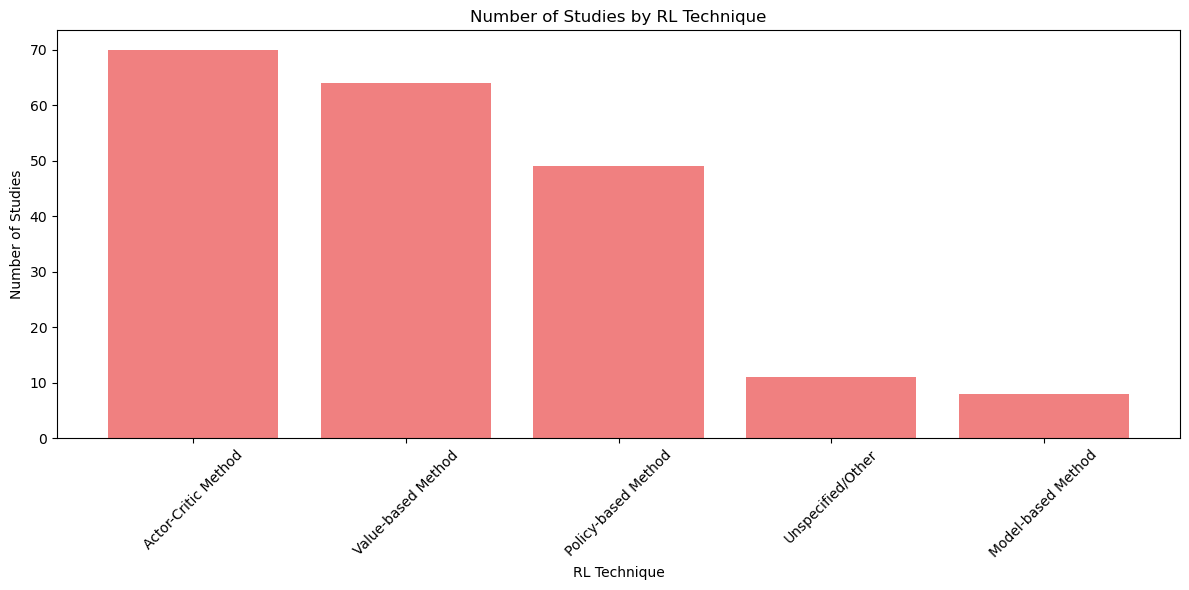

In [39]:
# plot tech
tech_counter = Counter(standardized_techs)
# Sort by count (descending)
sorted_tech = sorted(tech_counter.items(), key=lambda x: x[1], reverse=True)
tech_labels, tech_counts = zip(*sorted_tech)

# Plot sorted bar chart
plt.figure(figsize=(12, 6))
plt.bar(tech_labels, tech_counts, color='lightcoral')
plt.title('Number of Studies by RL Technique')
plt.xlabel('RL Technique')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


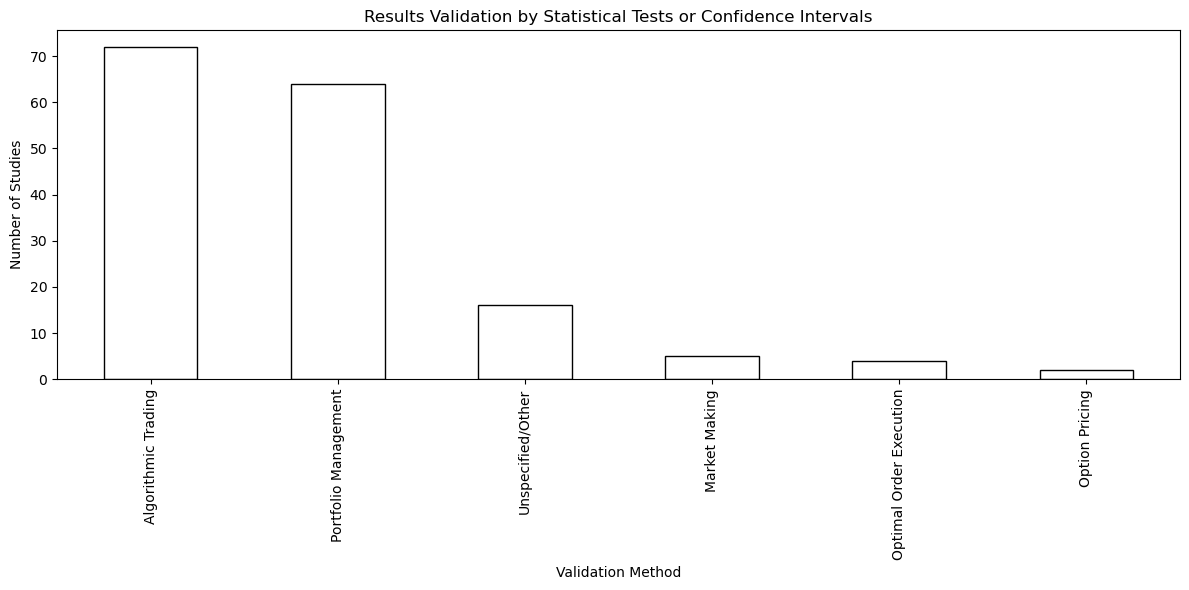

In [50]:
# Replace rows containing 'other' (case-insensitive) with 'Unspecified/Other'
mask = df_consensus['Which finance application is tested?'].str.contains('other', case=False, na=False)
df_consensus.loc[mask, 'Which finance application is tested?'] = 'Unspecified/Other'


# plot bar plot for 'Which finance application is tested?'

plt.figure(figsize=(12, 6))
df_consensus['Which finance application is tested?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Results Validation by Statistical Tests or Confidence Intervals')
plt.xlabel('Validation Method')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

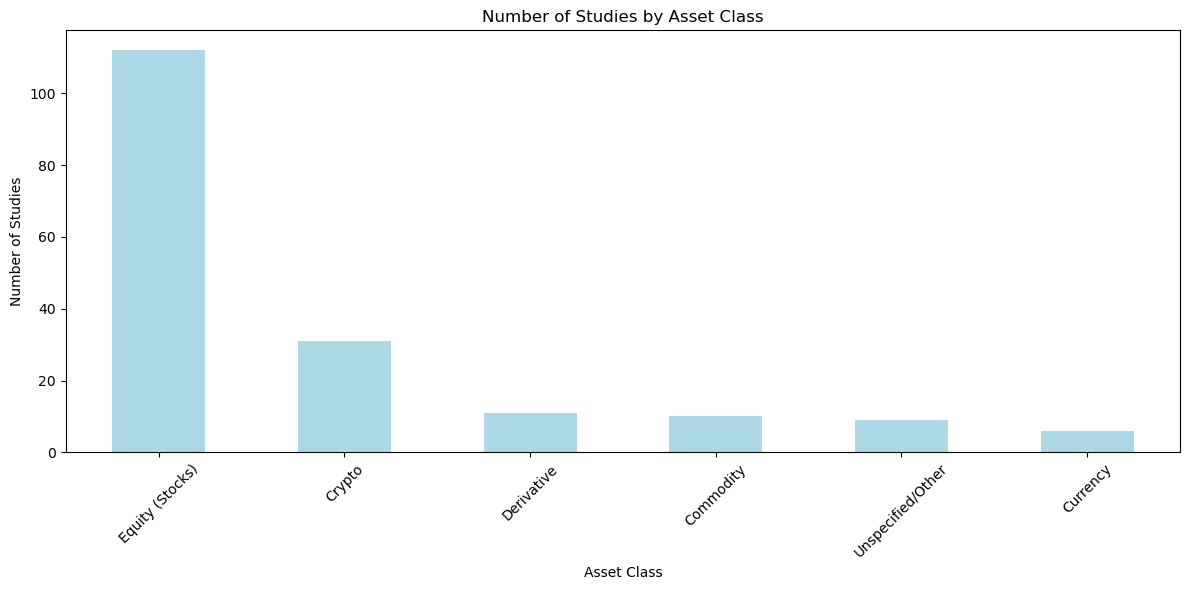

In [52]:

# Replace rows containing 'other' (case-insensitive) with 'Unspecified/Other'
mask = df_consensus['What asset classes are in the dataset?'].str.contains('other', case=False, na=False)
df_consensus.loc[mask, 'What asset classes are in the dataset?'] = 'Unspecified/Other'

# plot number of asset classes for  'What asset classes are in the dataset?'
asset_classes = df_consensus['What asset classes are in the dataset?'].dropna().str.split(';').explode().str.strip()
plt.figure(figsize=(12, 6))
asset_classes.value_counts().plot(kind='bar', color='lightblue')
plt.title('Number of Studies by Asset Class')
plt.xlabel('Asset Class')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\JanderM\AppData\Local\Temp\ipykernel_25112\641513139.py:13: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, max(num_asset_list) + 10)  # Adjust x-axis limit for better visibility


Number of studies with asset data: 156


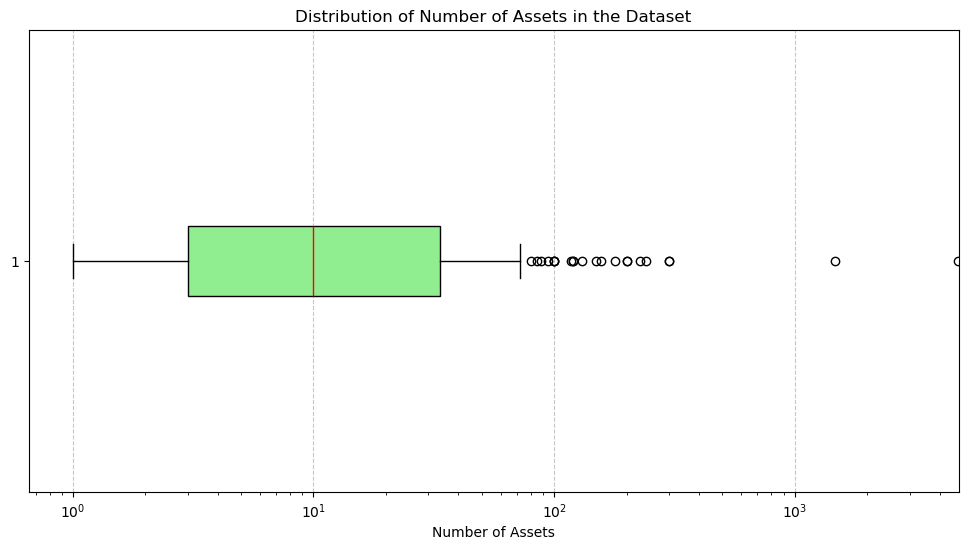

In [62]:
num_asset_list = df_consensus['What are the number of assets in the dataset?'].tolist()

# Convert the list of strings to a list of integers and drop NaN values
num_asset_list = [int(x) for x in num_asset_list if isinstance(x, str) and x.isdigit()]


# create box plot for number of assets
plt.figure(figsize=(12, 6))
plt.boxplot(num_asset_list, vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen', color='black'), medianprops=dict(color='red')) 
plt.xscale('log')  # Use logarithmic scale for better visibility
plt.title('Distribution of Number of Assets in the Dataset')
plt.xlabel('Number of Assets')
plt.xlim(0, max(num_asset_list) + 10)  # Adjust x-axis limit for better visibility
plt.grid(axis='x', linestyle='--', alpha=0.7)
print(f"Number of studies with asset data: {len(num_asset_list)}")

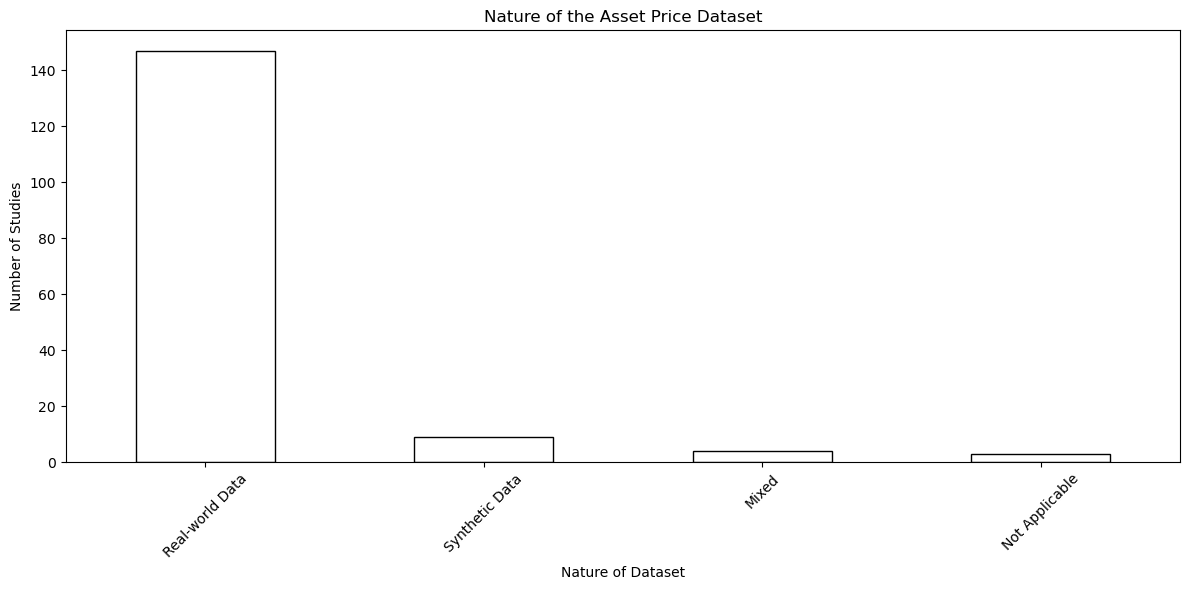

In [66]:
# replace other with unspecified/other
mask = df_consensus['What is the nature of the asset price dataset?'].str.contains('other', case=False, na=False)
df_consensus.loc[mask, 'What is the nature of the asset price dataset?'] = 'Not Applicable'

# box plot for 'What is the nature of the asset price dataset?'
plt.figure(figsize=(12, 6))
df_consensus['What is the nature of the asset price dataset?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Nature of the Asset Price Dataset')
plt.xlabel('Nature of Dataset')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

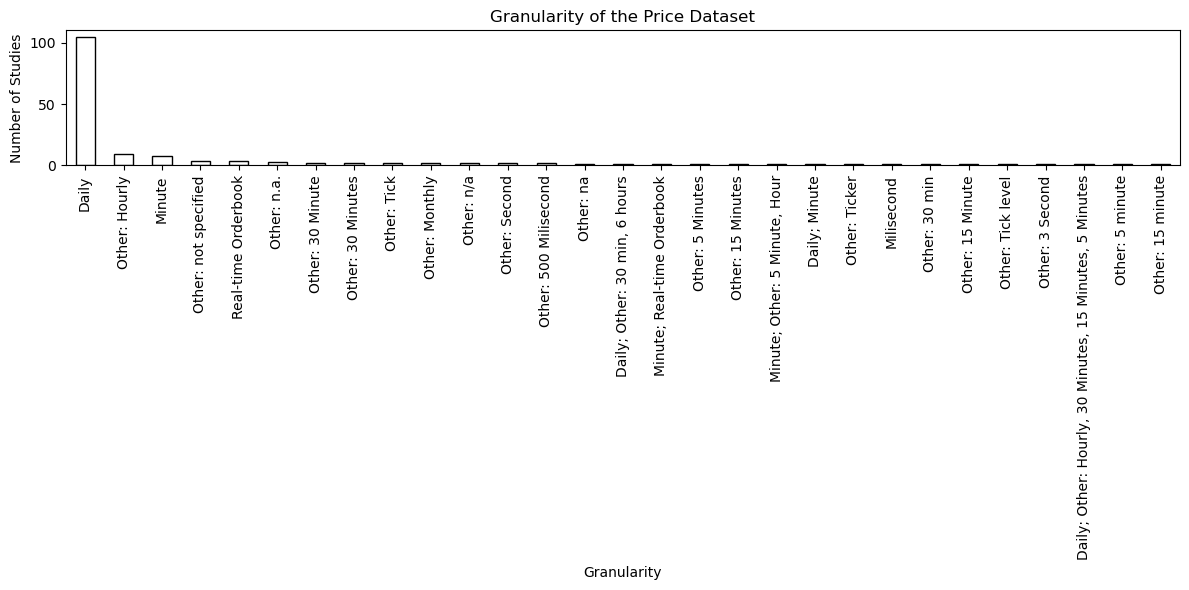

In [69]:
# plot for 'What is the granularity of the price dataset?'
plt.figure(figsize=(12, 6))
df_consensus['What is the granularity of the price dataset?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Granularity of the Price Dataset')
plt.xlabel('Granularity')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


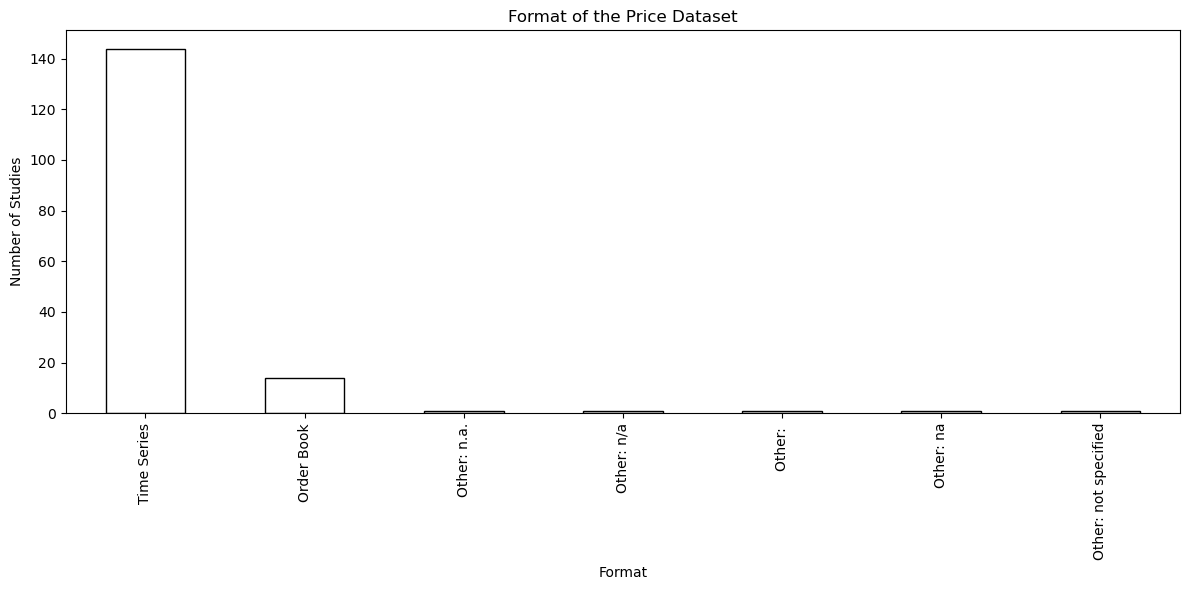

In [70]:
# plot for  'What is the format of the price dataset?'
plt.figure(figsize=(12, 6))
df_consensus['What is the format of the price dataset?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Format of the Price Dataset')
plt.xlabel('Format')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [81]:
raw_dataset = df_consensus['What other datasets are used in the study?'].fillna('None')
raw_dataset

0               Market Data
1               Other: n.a.
2                      None
3                      None
4               Market Data
               ...         
158                    None
159    Other: Economic Data
160                    None
161                    None
162                    None
Name: What other datasets are used in the study?, Length: 163, dtype: object

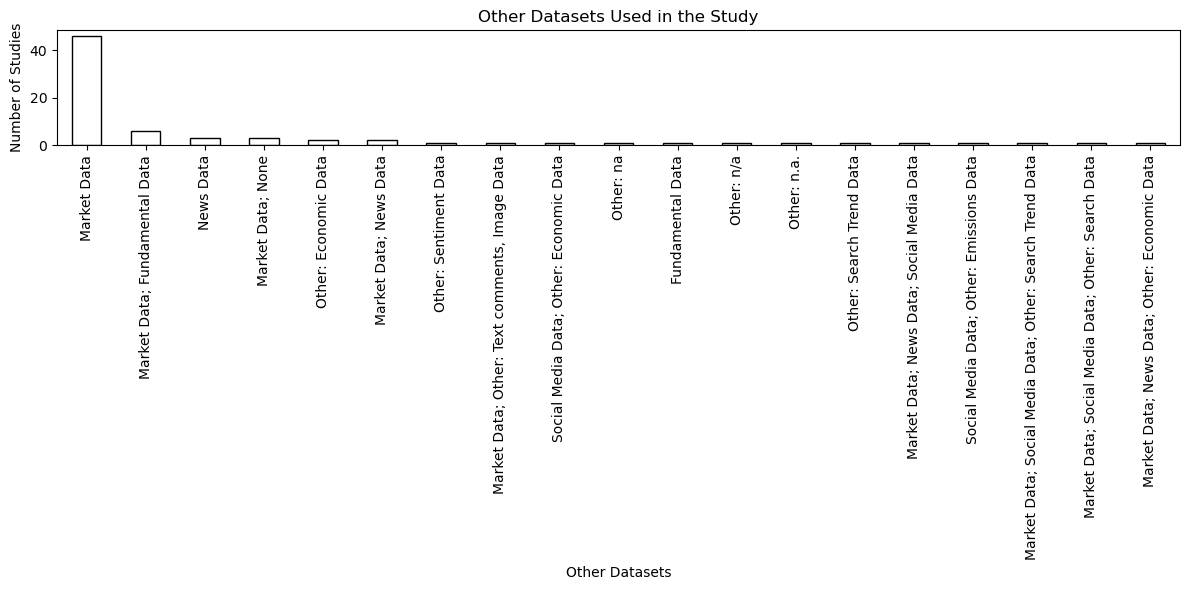

In [77]:
# plot for 'What other datasets are used in the study?'
plt.figure(figsize=(12, 6))
df_consensus['What other datasets are used in the study?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Other Datasets Used in the Study')
plt.xlabel('Other Datasets')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

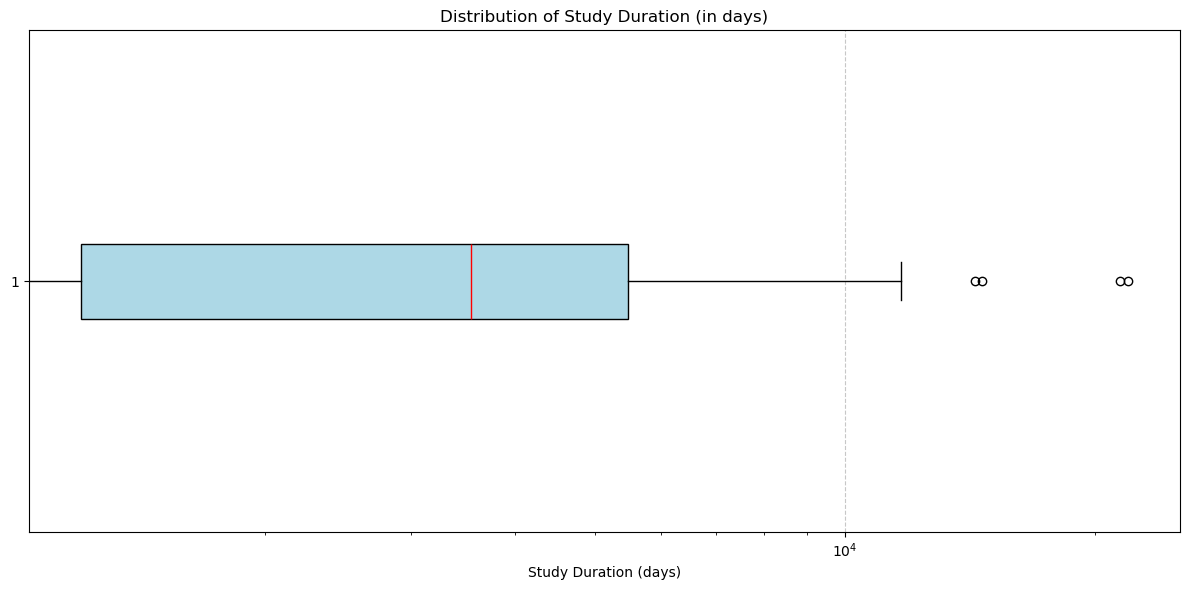

In [87]:
# plot for

df_consensus["Date Start"] = pd.to_datetime(df_consensus["Date Start"], errors='coerce')
df_consensus["Date End"] = pd.to_datetime(df_consensus["Date End"], errors='coerce')

# plot boxplot of study duration
plt.figure(figsize=(12, 6))
df_consensus['Study Duration'] = (df_consensus['Date End'] - df_consensus['Date Start']).dt.days
plt.boxplot(df_consensus['Study Duration'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red'))
plt.title('Distribution of Study Duration (in days)')
plt.xlabel('Study Duration (days)')
plt.xscale('log')  # Use logarithmic scale for better visibility
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Simulated example (replace this with your real data)
n = 160
df = pd.DataFrame({
    'Series': [f"TS_{i}" for i in range(n)],
    'Start': pd.date_range(start='2020-01-01', periods=n, freq='7D'),
    'End': pd.date_range(start='2020-04-01', periods=n, freq='10D')
})
df['Start'] = pd.to_datetime(df['Start'])
df['End'] = pd.to_datetime(df['End'])
df['Duration'] = (df['End'] - df['Start']).dt.days

# Sort by start date (optional)
df = df.sort_values('Start')

# Plot
fig, ax = plt.subplots(figsize=(12, int(n/6)))  # Adjust height to fit
ax.barh(df['Series'], df['Duration'], left=df['Start'], color='steelblue')

# Format date axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.set_xlabel('Date')
ax.set_title('Start and End Dates of Time Series')
plt.tight_layout()
plt.show()


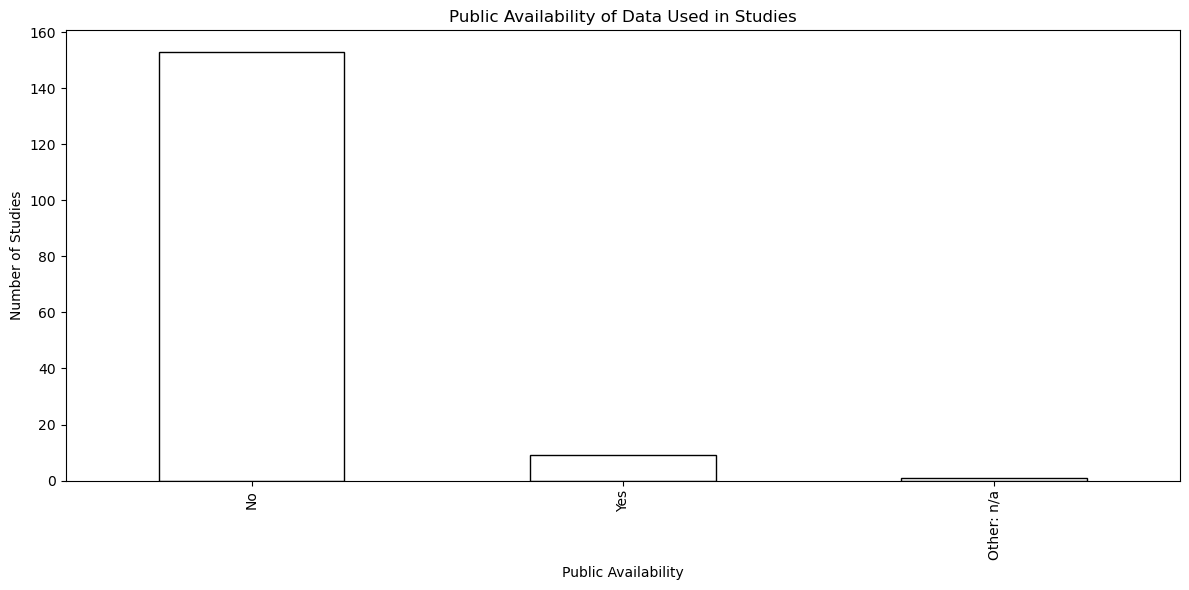

In [88]:
# plot 'Is all used and produced data made publicly available and referred to in the article?'

plt.figure(figsize=(12, 6))
df_consensus['Is all used and produced data made publicly available and referred to in the article?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Public Availability of Data Used in Studies')
plt.xlabel('Public Availability')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

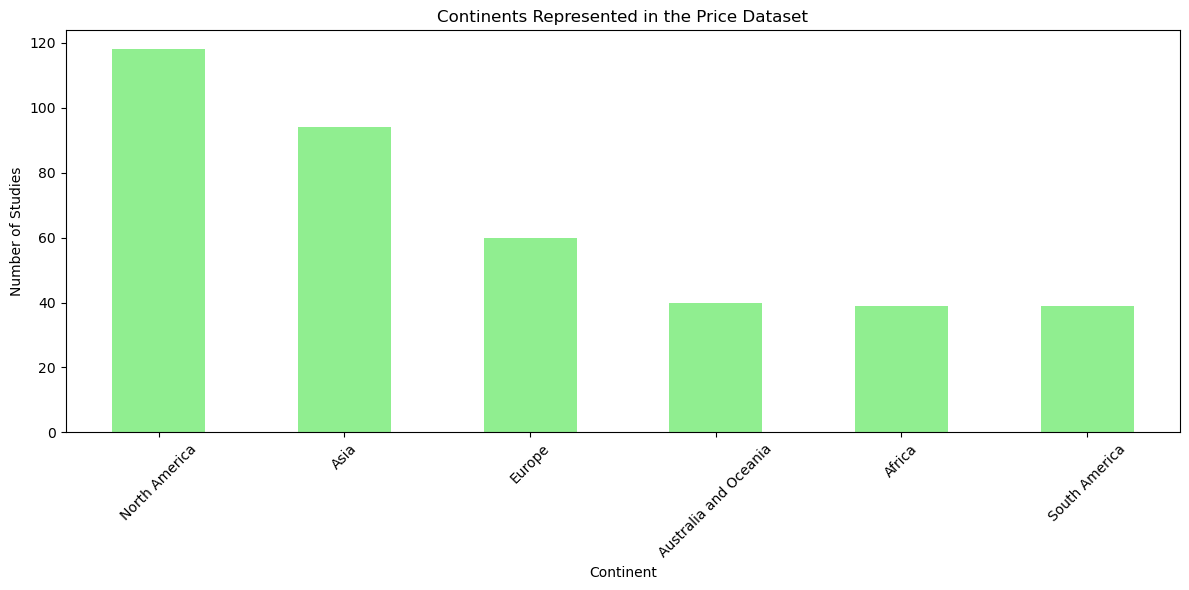

In [90]:
# split the 'Which continents are represented in the price dataset?' column into a list of continents by splitting on semicolon and stripping whitespace

continents_list = df_consensus['Which continents are represented in the price dataset?'].dropna().str.split(';').explode().str.strip()

# plot for 'Which continents are represented in the price dataset?'
plt.figure(figsize=(12, 6))
continents_list.value_counts().plot(kind='bar', color='lightgreen')
plt.title('Continents Represented in the Price Dataset')
plt.xlabel('Continent')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

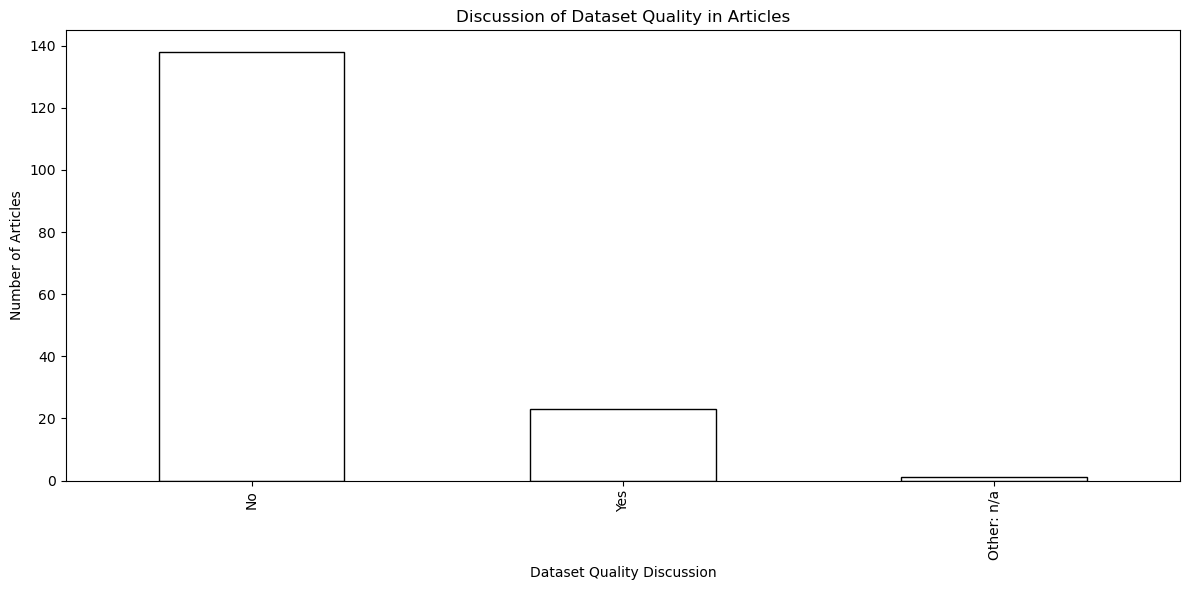

In [91]:
# plot 'Is dataset quality discussed in article?'
plt.figure(figsize=(12, 6))
df_consensus['Is dataset quality discussed in article?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Discussion of Dataset Quality in Articles')
plt.xlabel('Dataset Quality Discussion')
plt.ylabel('Number of Articles')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


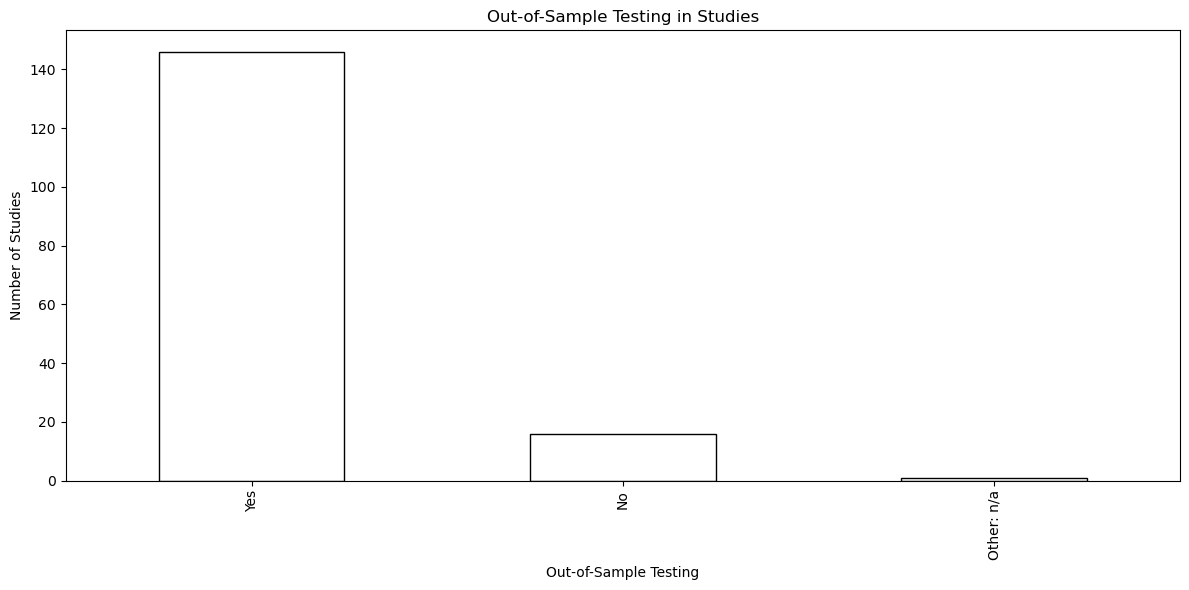

In [93]:
# plot  'Is out-of-sample testing applied?
plt.figure(figsize=(12, 6))
df_consensus['Is out-of-sample testing applied?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Out-of-Sample Testing in Studies')
plt.xlabel('Out-of-Sample Testing')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

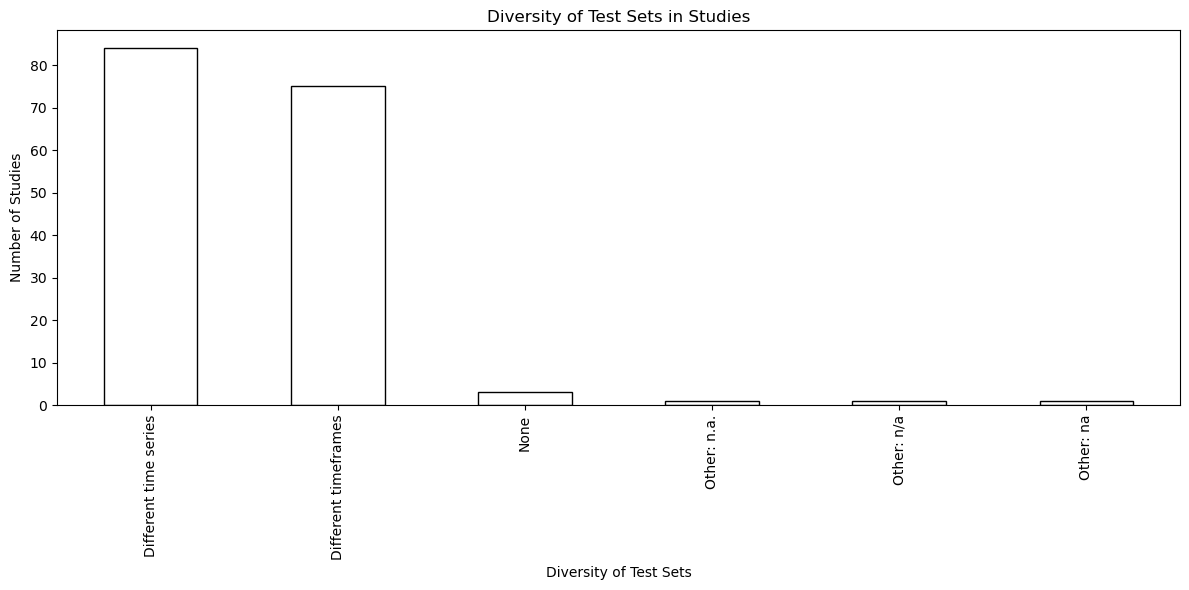

In [97]:
# split the 'Was the model tested on diverse test sets?' column into a list of types by splitting on semicolon and stripping whitespace
out_sample_types = df_consensus['Was the model tested on diverse test sets?'].dropna().str.split(';').explode().str.strip()

# plot 'Was the model tested on diverse test sets?'
plt.figure(figsize=(12, 6))
out_sample_types.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Diversity of Test Sets in Studies')
plt.xlabel('Diversity of Test Sets')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


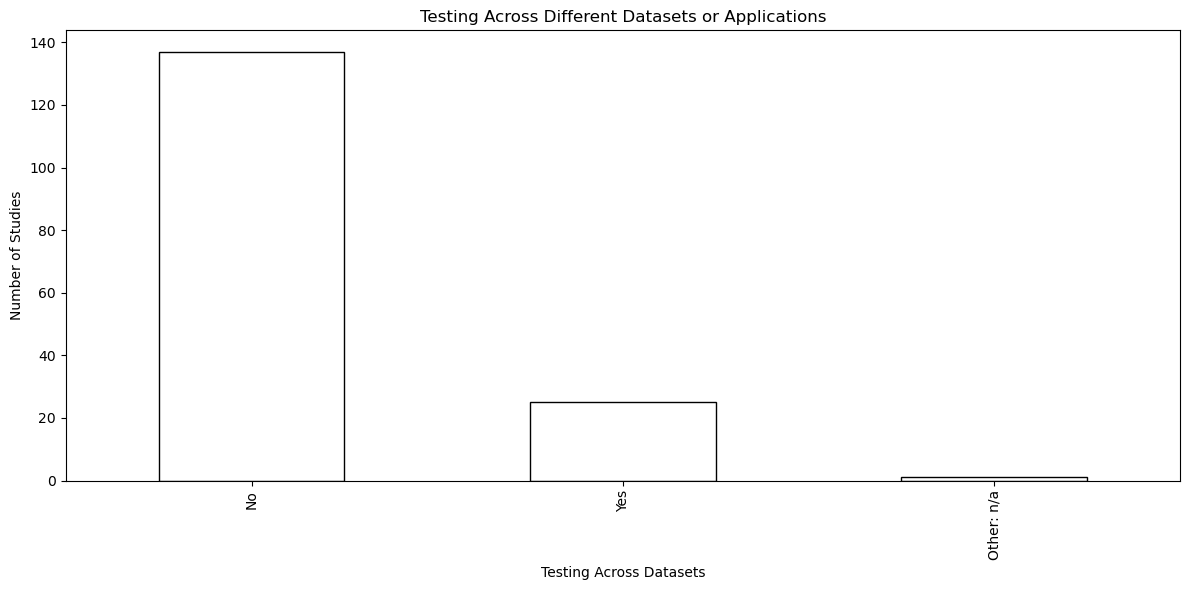

In [98]:
# plot 'Was the model tested across different datasets or applications?'

plt.figure(figsize=(12, 6))
df_consensus['Was the model tested across different datasets or applications?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Testing Across Different Datasets or Applications')
plt.xlabel('Testing Across Datasets')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

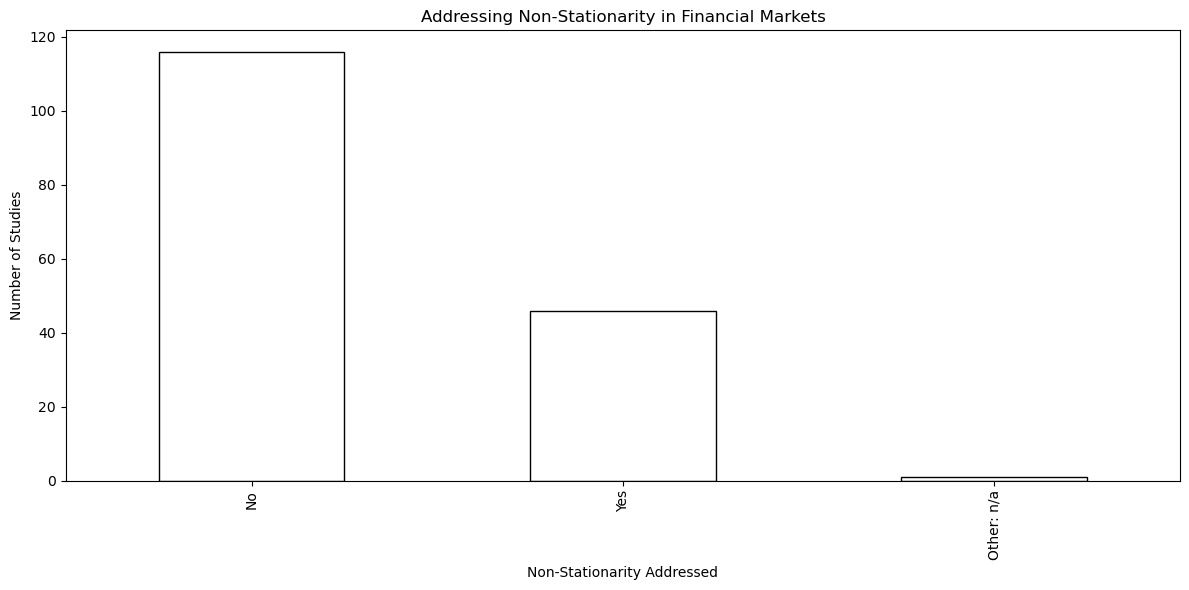

In [99]:
# plot 'Is the non-stationarity problem of financial markets explicitly addressed?'
plt.figure(figsize=(12, 6))
df_consensus['Is the non-stationarity problem of financial markets explicitly addressed?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Addressing Non-Stationarity in Financial Markets')
plt.xlabel('Non-Stationarity Addressed')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


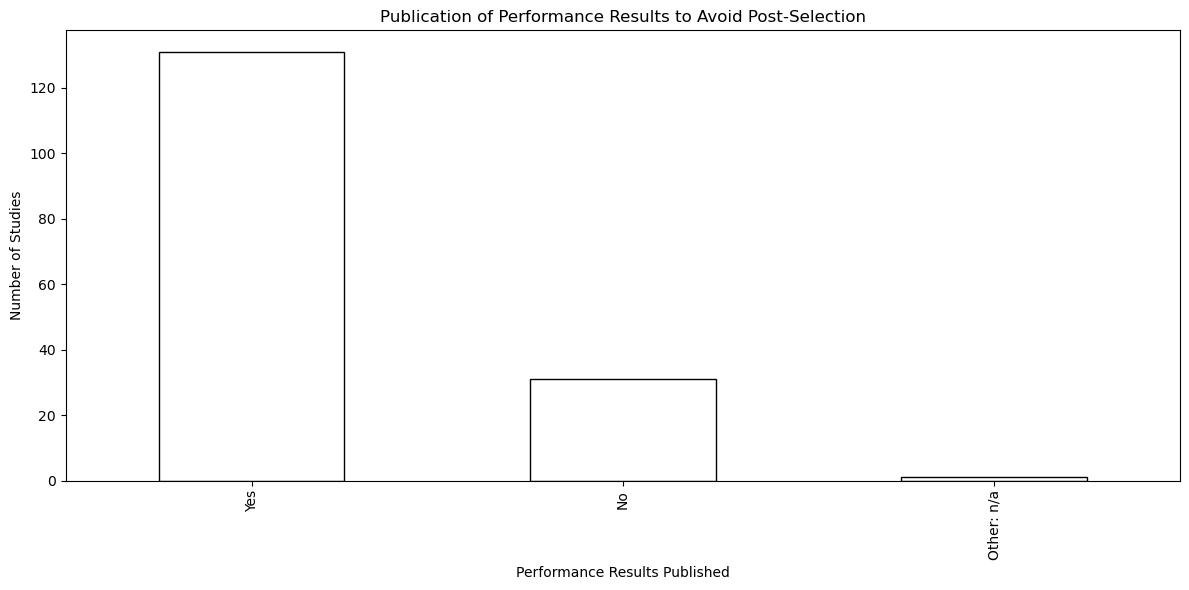

In [100]:
# plot 'Are all performance results published to avoid post-selection?'
plt.figure(figsize=(12, 6))
df_consensus['Are all performance results published to avoid post-selection?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Publication of Performance Results to Avoid Post-Selection')
plt.xlabel('Performance Results Published')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


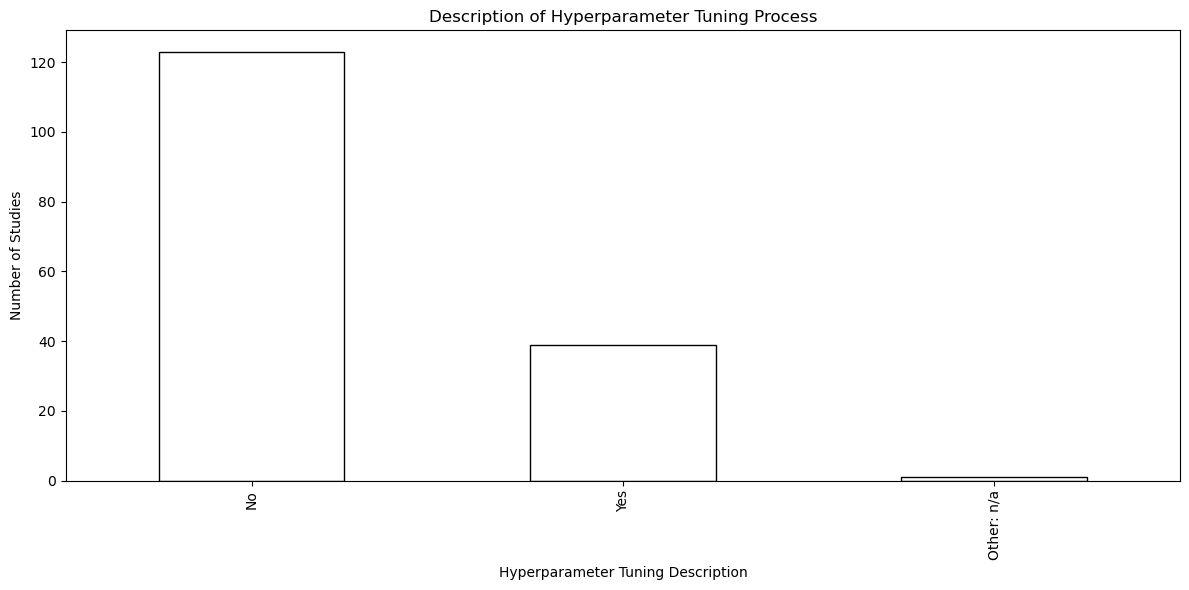

In [101]:
# plot  'Is the process of hyperparameter tuning explicitly described?'
plt.figure(figsize=(12, 6))
df_consensus['Is the process of hyperparameter tuning explicitly described?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Description of Hyperparameter Tuning Process')
plt.xlabel('Hyperparameter Tuning Description')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


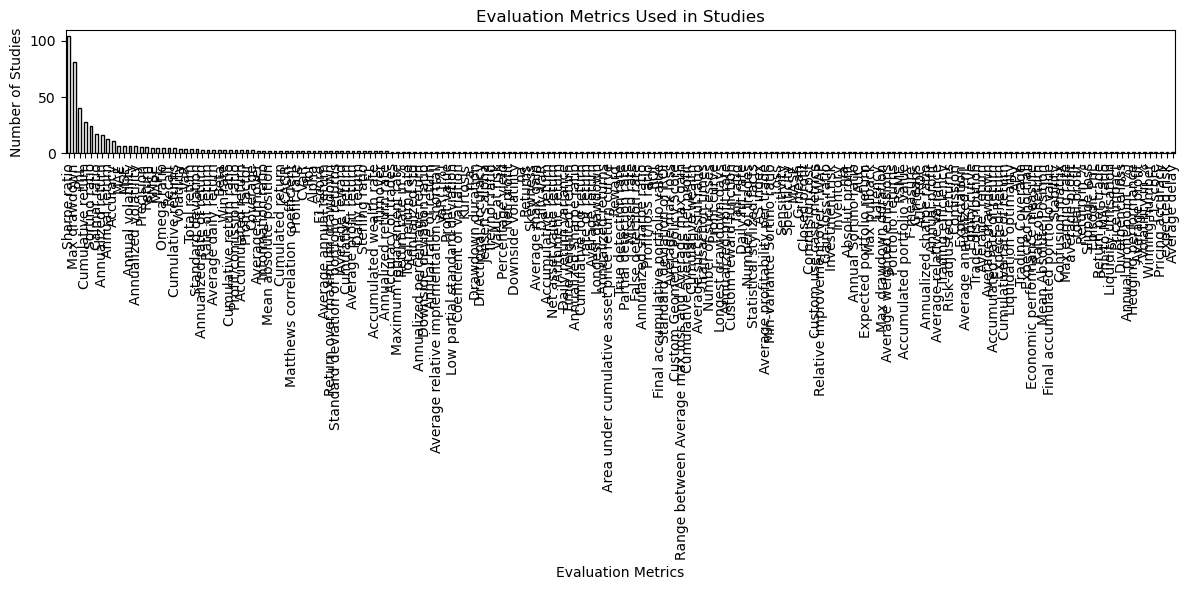

In [104]:
# split the 'Which evaluation metrics are used?' column into a list of metrics by splitting on semicolon and on comma and remove 'Other: ' and stripping whitespace
metrics_list = df_consensus['Which evaluation metrics are used?'].dropna().str.split(';|,').explode().str.strip().str.replace('Other: ', '', regex=False)

# plot 'Which evaluation metrics are used?'
plt.figure(figsize=(12, 6))
metrics_list.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Evaluation Metrics Used in Studies')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [105]:
metrics_list.unique()

array(['Sharpe ratio', 'Sortino ratio', 'Cumulated return', 'n.a.', 'PnL',
       'Return', 'Volatility', 'MSE', 'MAE', 'RMSE',
       'Directional Accuracy', 'Max drawdown', 'Calmar ratio',
       'Cumulative returns', 'F1', 'Precision', 'Recall',
       'Confusion matrix', 'MAPE', 'Liquidation optimality', 'Coverage',
       'Return over maximum drawdown', 'Expected Return',
       'Cumulative return', 'Annualized return', 'Return in %',
       'Omega ratio', 'Volatility in %', 'Expected portfolio return',
       'Standard deviation of portfolio returns',
       'Average relative variance', 'Accumulated portfolio value',
       'Sterling ratio', 'Average turnover', 'Rate of Return',
       'Max drawdown duration', 'Average weighted emissions',
       'Portfolio returns', 'VaR', 'RSME', 'Accuracy', 'F-measure',
       'G-means', 'AUC-ROC', 'Accumulated wealth rate',
       'Average profit return', 'Annualized return rate',
       'Annualized sharpe ratio', 'Annual profit', 'Annual vol

The data here is really messy. Not sure how to visualize and discuss this...

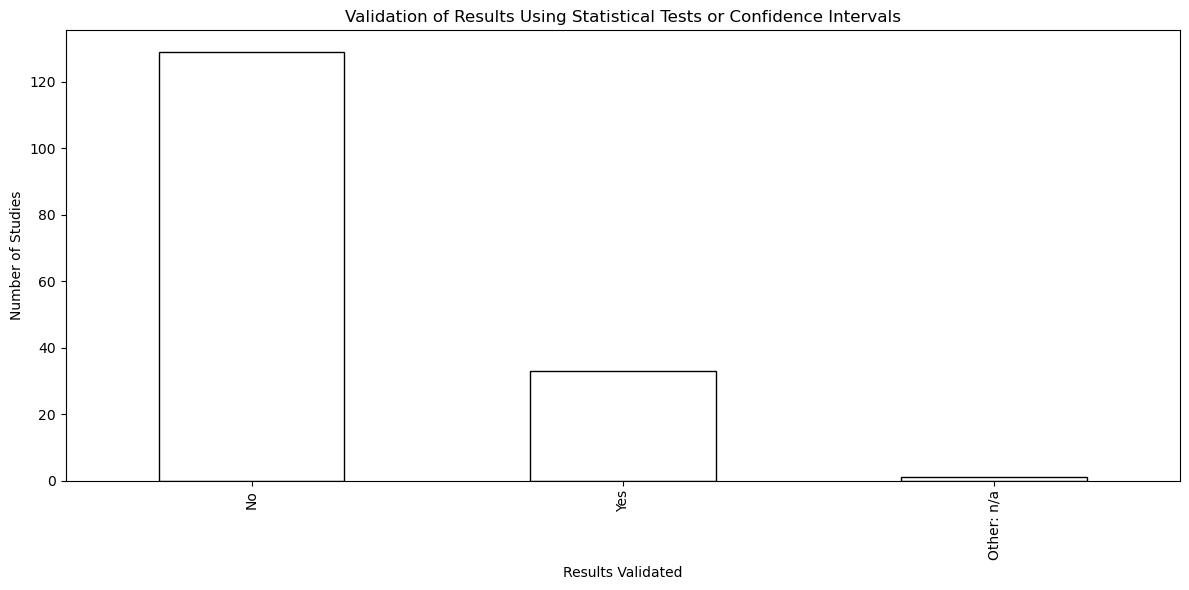

In [106]:
# plot 'Are results validated using statistical tests or confidence intervals?'
plt.figure(figsize=(12, 6))
df_consensus['Are results validated using statistical tests or confidence intervals?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Validation of Results Using Statistical Tests or Confidence Intervals')
plt.xlabel('Results Validated')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


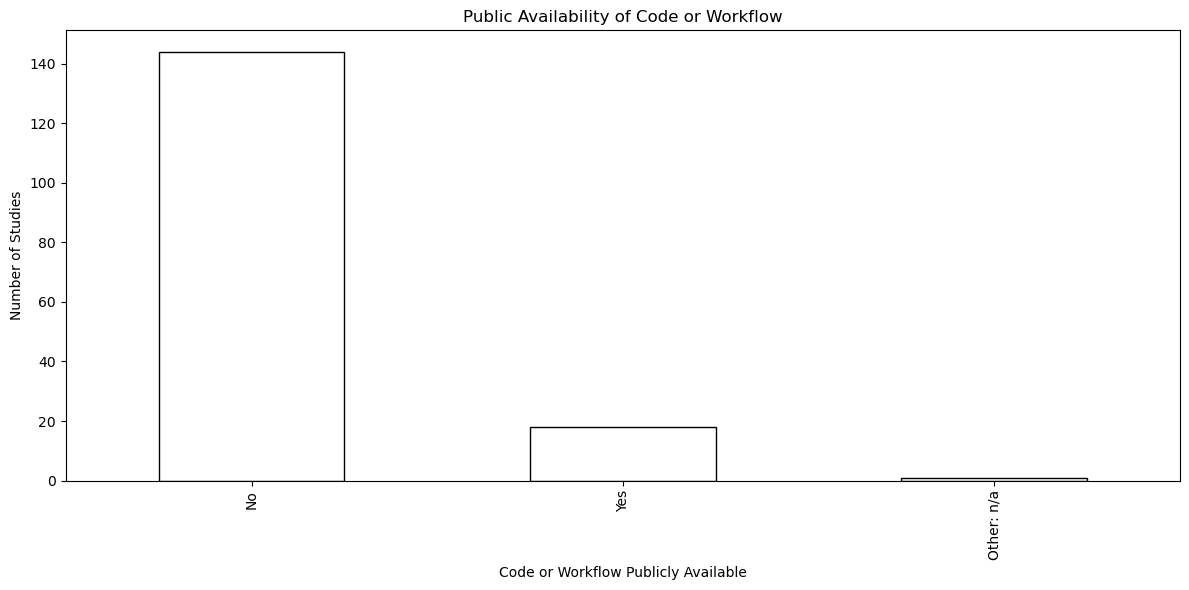

In [107]:
# plot 'Is the code or workflow made publicly available and referred to?'
plt.figure(figsize=(12, 6))
df_consensus['Is the code or workflow made publicly available and referred to?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Public Availability of Code or Workflow')
plt.xlabel('Code or Workflow Publicly Available')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


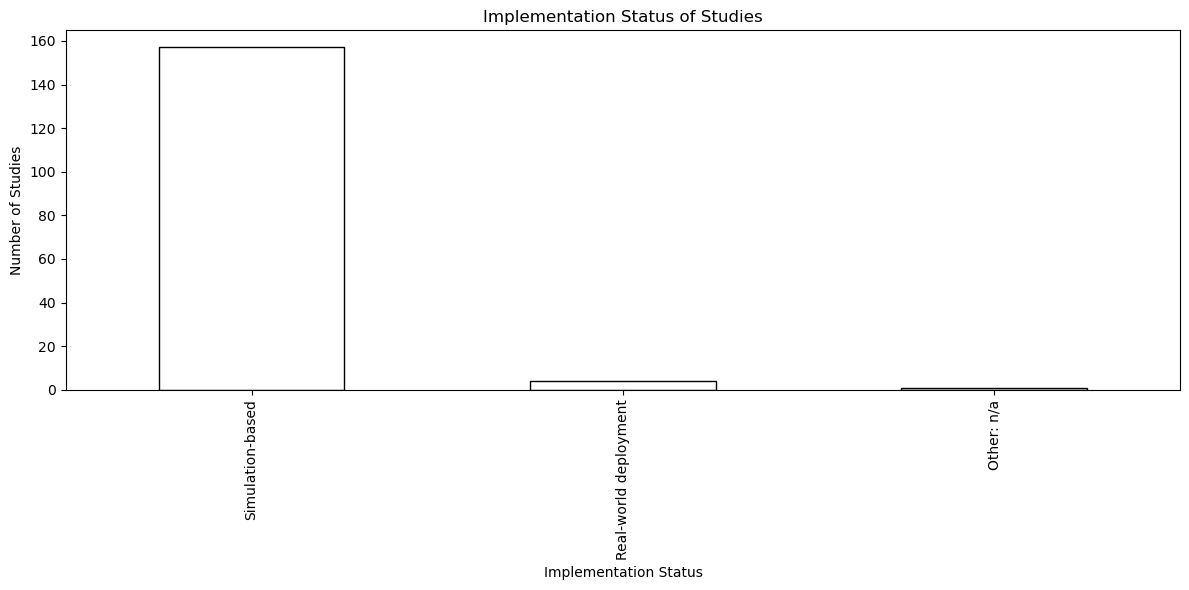

In [108]:
# plot 'What is the implementation status?'
plt.figure(figsize=(12, 6))
df_consensus['What is the implementation status?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Implementation Status of Studies')
plt.xlabel('Implementation Status')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


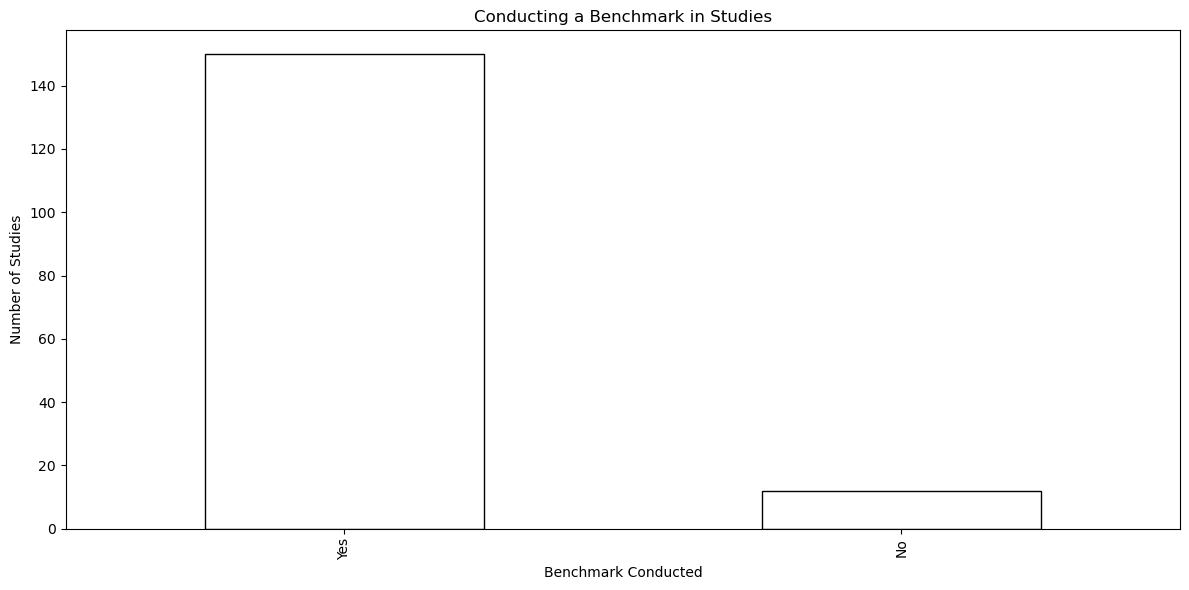

In [109]:
# plot 'Does the study conduct a benchmark?'
plt.figure(figsize=(12, 6))
df_consensus['Does the study conduct a benchmark?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Conducting a Benchmark in Studies')
plt.xlabel('Benchmark Conducted')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


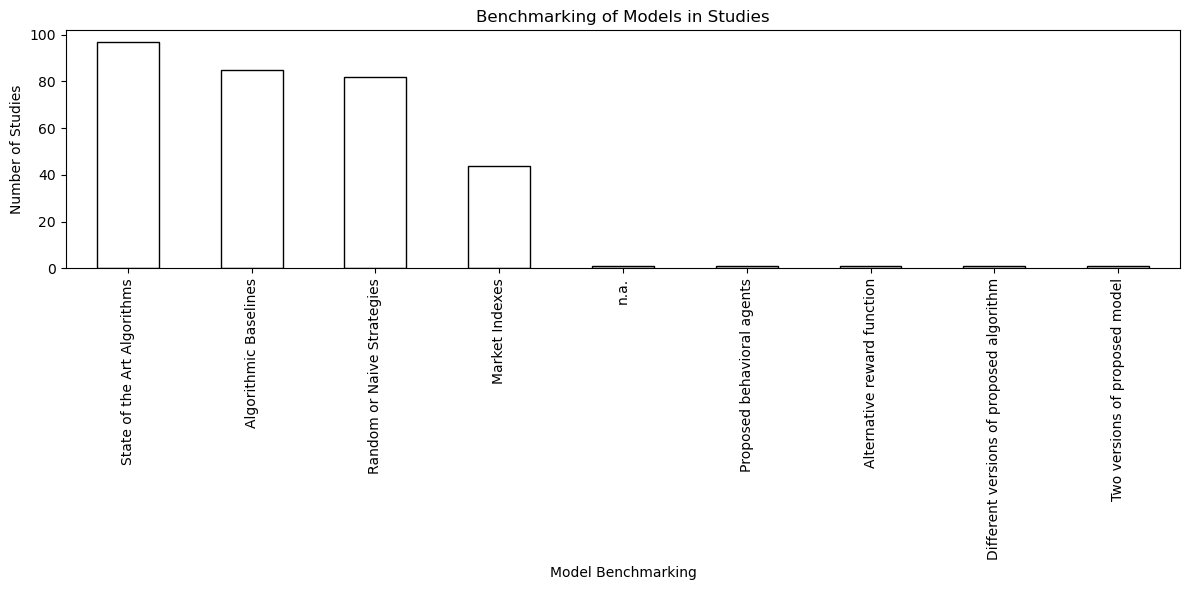

In [111]:
# split the 'What is the model benchmarked against?' column into a list of metrics by splitting on semicolon and on comma and remove 'Other: ' and stripping whitespace
benchmark_list = df_consensus['What is the model benchmarked against?'].dropna().str.split(';|,').explode().str.strip().str.replace('Other: ', '', regex=False)

# plot 'What is the model benchmarked against?'
plt.figure(figsize=(12, 6))
benchmark_list.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Benchmarking of Models in Studies')
plt.xlabel('Model Benchmarking')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

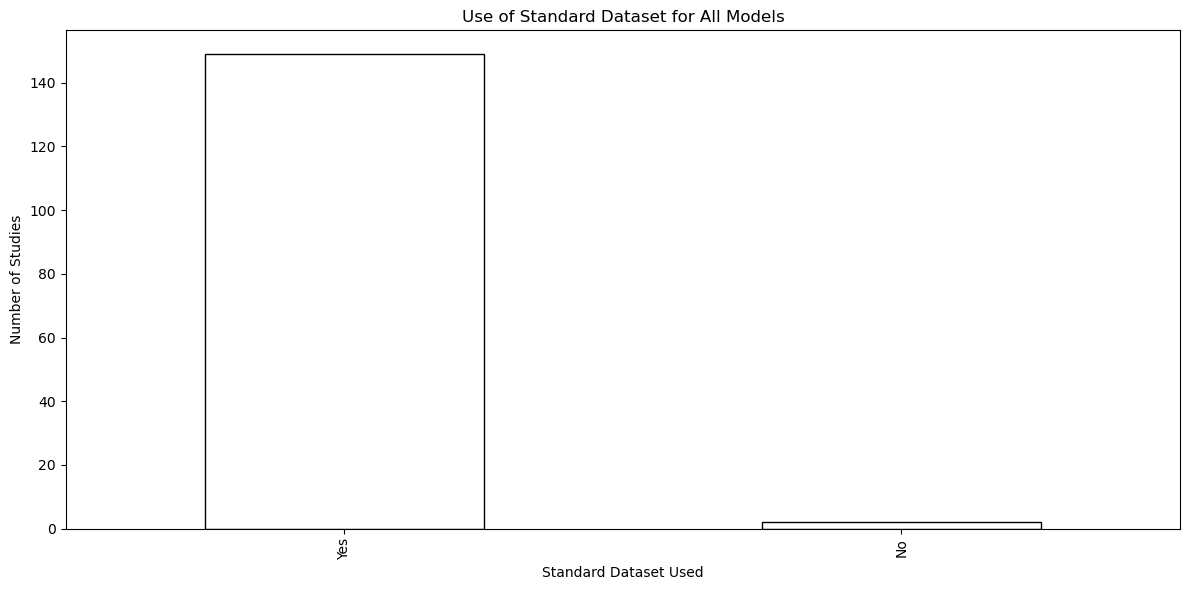

In [112]:
# plot 'Is a standard dataset used for all models?'
plt.figure(figsize=(12, 6))
df_consensus['Is a standard dataset used for all models?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Use of Standard Dataset for All Models')
plt.xlabel('Standard Dataset Used')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

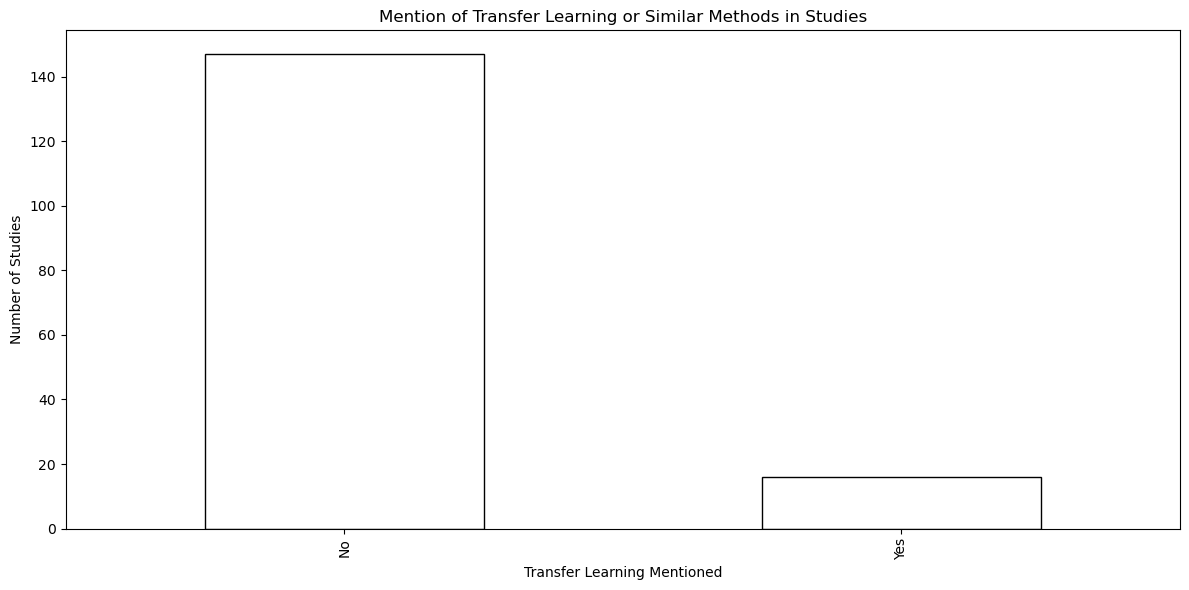

In [113]:
# plot 'Does study mention Transfer Learning or similar method as potential avenue for research?'
plt.figure(figsize=(12, 6))
df_consensus['Does study mention Transfer Learning or similar method as potential avenue for research?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Mention of Transfer Learning or Similar Methods in Studies')
plt.xlabel('Transfer Learning Mentioned')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


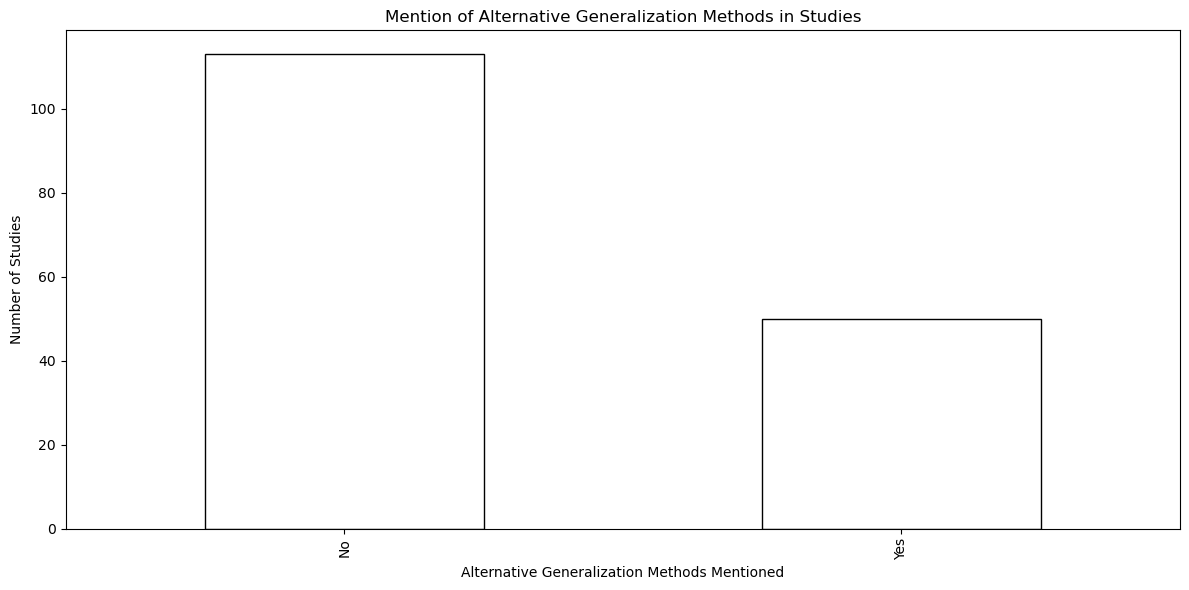

In [115]:
# plot 'Does study mention alternative generalization methods?'
plt.figure(figsize=(12, 6))
df_consensus['Does study mention alternative generalization methods?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Mention of Alternative Generalization Methods in Studies')
plt.xlabel('Alternative Generalization Methods Mentioned')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


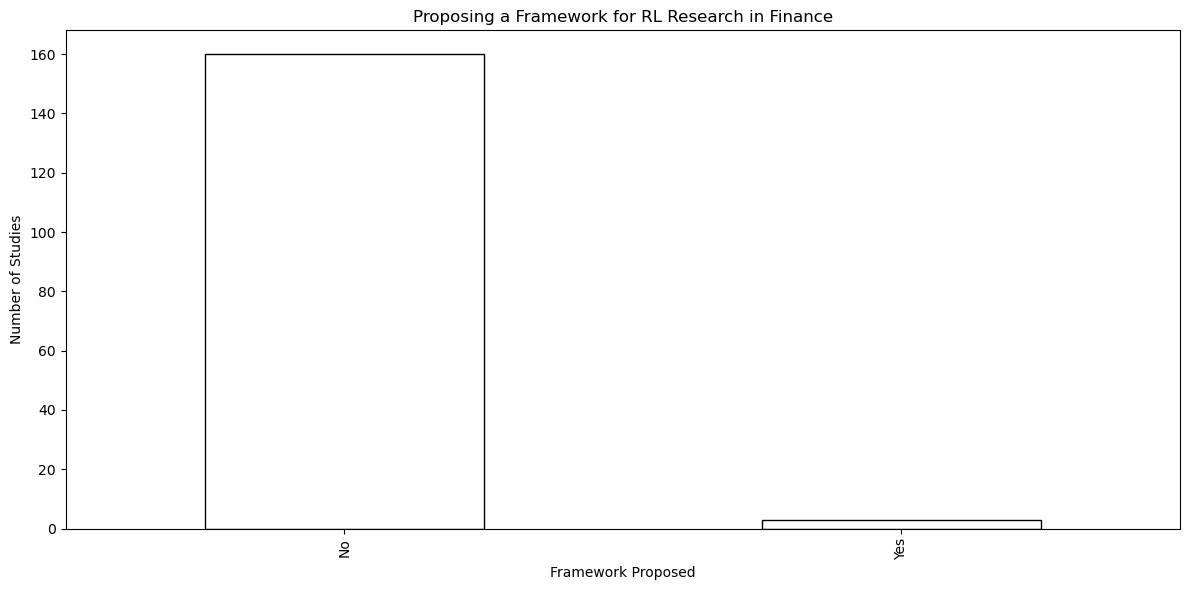

In [116]:
# plot 'Does the study propose a framework to structure RL research in finance?'
plt.figure(figsize=(12, 6))
df_consensus['Does the study propose a framework to structure RL research in finance?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Proposing a Framework for RL Research in Finance')
plt.xlabel('Framework Proposed')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [41]:
df_consensus.columns

Index(['Covidence #', 'Study ID', 'Title', 'Reviewer Name', 'Study ID (dup)',
       'Title (dup)', 'Journal Subject Area (Scimago classification)',
       'What is the type of study?', 'What are the objectives of the study?',
       'Which RL technique is used?', 'Which finance application is tested?',
       'What are the stated key results of the study?',
       'What are the stated limitations of the study?',
       'What asset classes are in the dataset?',
       'What are the number of assets in the dataset?',
       'What is the nature of the asset price dataset?',
       'What is the granularity of the price dataset?',
       'What is the format of the price dataset?',
       'What other datasets are used in the study?',
       'What is the time frame of time series data used?:', 'Date Start',
       'Date End',
       'Is all used and produced data made publicly available and referred to in the article?',
       'Which continents are represented in the price dataset?',
       

# 2 Thematic Synthesis

Notes:

- remove secondary papers from analysis